# **Tarea 3 2026**

Constanza Luarte Salazar
2022428147

# 1. Carga de bases de datos y ajustes necesarios
Se realizaron los siguientes ajustes a la base de datos según los analisis preliminares:
| Variable | Problema detectado | Decision |
|---|---|---|
| vive_padre | solo 16 (0.04%) casos en que tiene más de un padre (2)| Excluir de df por baja representatividad, podróa introducir alta varianza|
| vive_madre |solo 70 (0.17%) casos en que tiene más de un madre (2) | Excluir de df |
| act_fisica | 1435 valores faltantes (3.4%) | Dropna |
| educm | 551 valores faltantes (1.3%) | Dropna |
| sk7 | La escala de evaluación está invertida c/r a las demás (1=nunca agresivo, mayor número es negativo) | Invertir (sk7 = 6 - sk7) |

Además, se creó un nuevo df que contiene solo las variables sk

### 1.1 Carga de base de datos y librerias 

In [1]:
# Instalacion de librerias no estandar
import subprocess, sys, warnings
for pkg in ['factor_analyzer', 'semopy', 'xgboost', 'nltk']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=False)

# Librerias generales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time, re
warnings.filterwarnings('ignore')

# Factor Analysis y CFA
from sklearn.utils.validation import check_array as _orig_check_array
def _patched_check_array(*args, force_all_finite=None, **kwargs):
    if force_all_finite is not None and 'ensure_all_finite' not in kwargs:
        kwargs['ensure_all_finite'] = force_all_finite
    return _orig_check_array(*args, **kwargs)
import factor_analyzer.factor_analyzer as _fa_mod
_fa_mod.check_array = _patched_check_array

from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
import semopy

# Scikit-learn: modelos, metricas y utilidades
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score, silhouette_score
)
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer

# XGBoost y NLP
import xgboost as xgb
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.options.display.float_format = '{:.2f}'.format


In [2]:
df = pd.read_csv('junaeb2n.csv')
df.head()

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work,narrative
0,1,85,0.75,1,1,1,1,1,2,1,...,2,2,3,2,NaN,0,11.00,11,-1,Las habilidades socioemocionales estan bien es...
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,1,1,5.00,0,8.00,8,1,"Exhibe un perfil socioemocional muy solido, si..."
2,1,68,0.27,0,1,2,2,3,2,1,...,3,2,1,3,NaN,1,13.00,13,1,"Su perfil socioemocional aun esta madurando, s..."
3,1,84,2.05,1,1,1,1,1,1,1,...,1,1,1,1,2.00,1,16.00,12,-1,"Alcanza un nivel socioemocional muy alto, de m..."
4,0,86,1.05,1,1,1,1,1,1,1,...,1,1,1,1,1.00,1,17.00,15,0,"Exhibe un perfil socioemocional muy solido, de..."


### 1.2 Tipos de datos, dimensiones y valores faltantes

In [3]:
print(f"Dimensiones del DataFrame: {df.shape}\n")
print("Tipos de datos y valores no nulos:")
print(df.info())

print("\nValores faltantes:")
missing = df.isnull().sum()
print(pd.DataFrame({'Faltantes': missing, '% Faltantes': (missing / len(df) * 100).round(2)})[missing > 0])

for col in ['vive_padre', 'vive_madre', 'madre_work']:
    print(f"\nDistribucion de {col}:")
    print(df[col].value_counts(dropna=False))

Dimensiones del DataFrame: (41854, 24)

Tipos de datos y valores no nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41854 entries, 0 to 41853
Data columns (total 24 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sexo        41854 non-null  int64  
 1   edad        41854 non-null  int64  
 2   imce        41854 non-null  float64
 3   vive_padre  41854 non-null  int64  
 4   vive_madre  41854 non-null  int64  
 5   sk1         41854 non-null  int64  
 6   sk2         41854 non-null  int64  
 7   sk3         41854 non-null  int64  
 8   sk4         41854 non-null  int64  
 9   sk5         41854 non-null  int64  
 10  sk6         41854 non-null  int64  
 11  sk7         41854 non-null  int64  
 12  sk8         41854 non-null  int64  
 13  sk9         41854 non-null  int64  
 14  sk10        41854 non-null  int64  
 15  sk11        41854 non-null  int64  
 16  sk12        41854 non-null  int64  
 17  sk13        41854 non-null  int6

### 1.3 Ajustes

In [4]:
# Limpieza de datos 
df = df.dropna()
df = df[(df['vive_padre'] != 2) & (df['vive_madre'] != 2)]

# Inversion de sk7 (1=nunca agresivo -> 5=nunca agresivo = positivo)
df['sk7'] = 6 - df['sk7']

sk_labels = [f'sk{i}' for i in range(1, 14)]
df_sk = df[sk_labels].copy()
df_sk.head(3)

,sk1,sk2,sk3,sk4,sk5,sk6,sk7,sk8,sk9,sk10,sk11,sk12,sk13
1,1,1,1,1,1,1,2,1,1,1,1,1,1
3,1,1,1,1,1,1,4,1,1,1,1,1,1
4,1,1,1,1,1,1,3,1,1,1,1,1,1


### 1.4 Distribuciones y outliers 

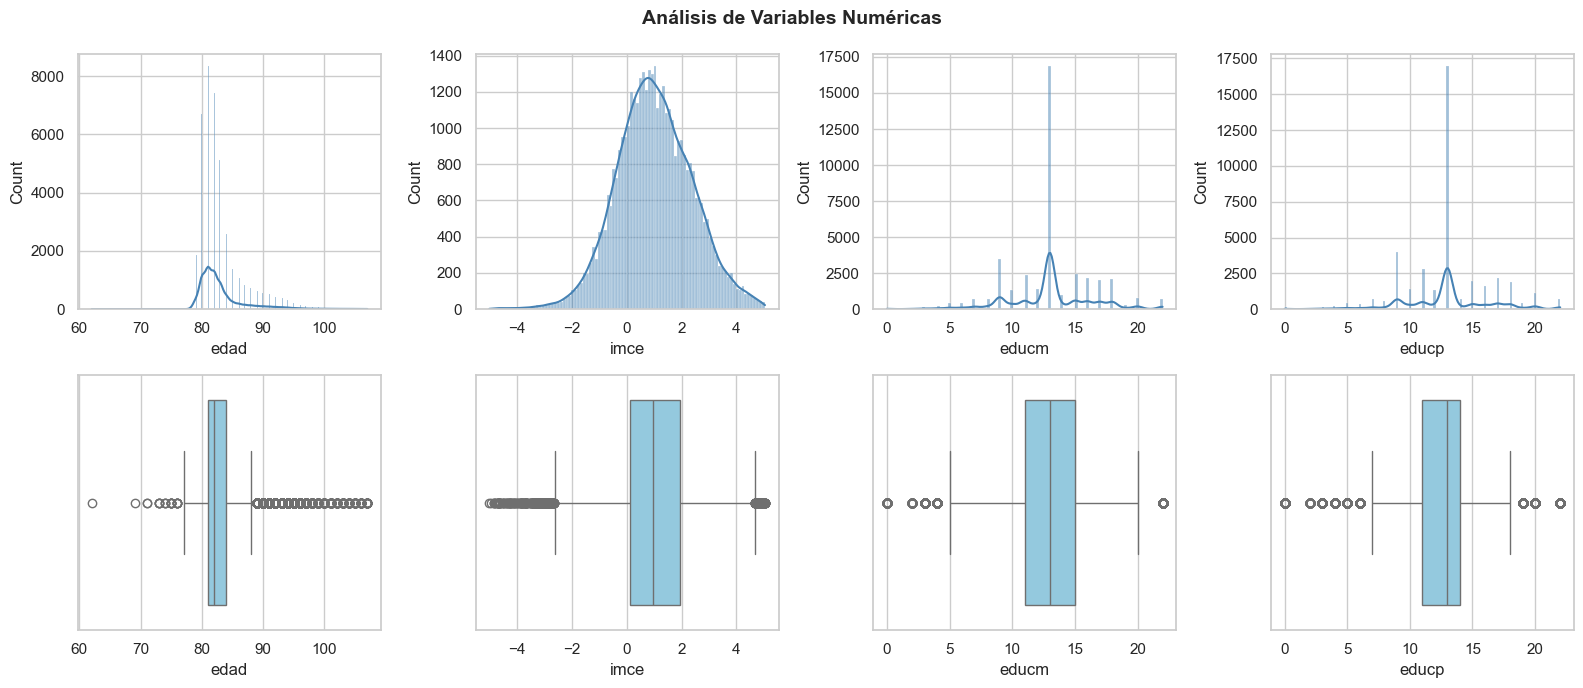

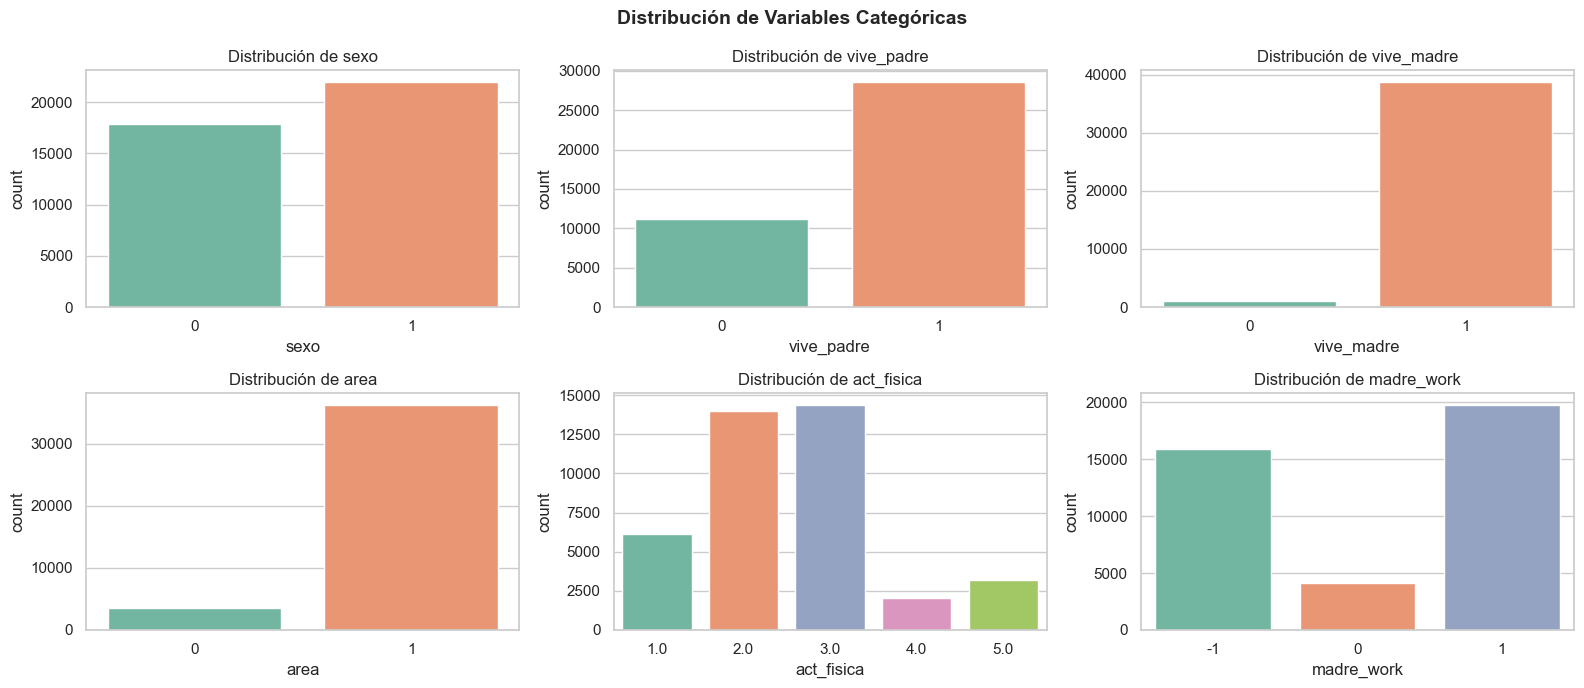

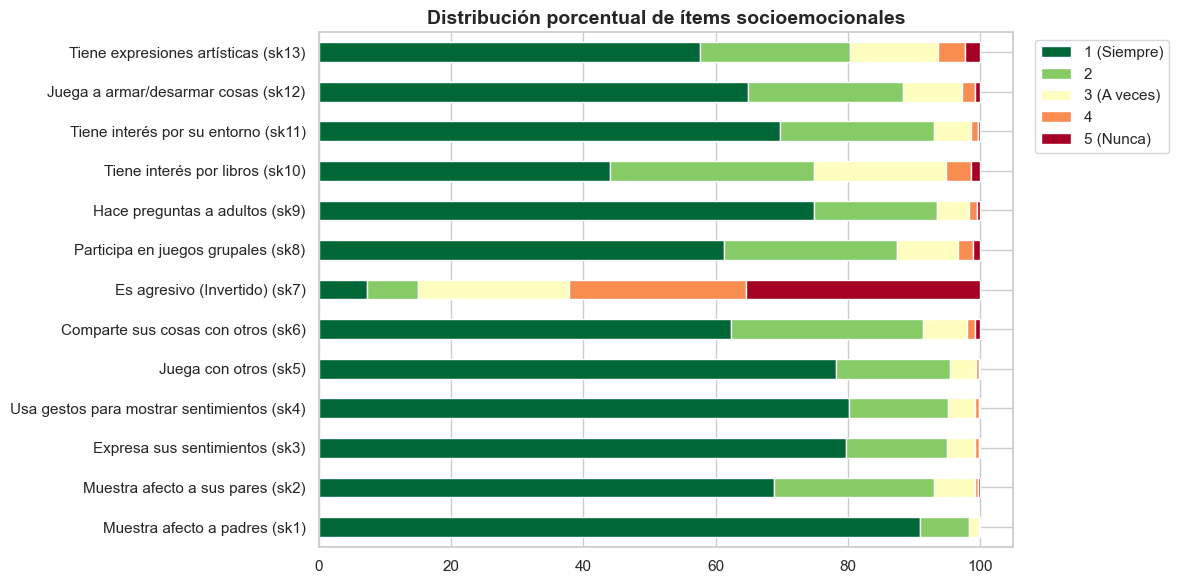

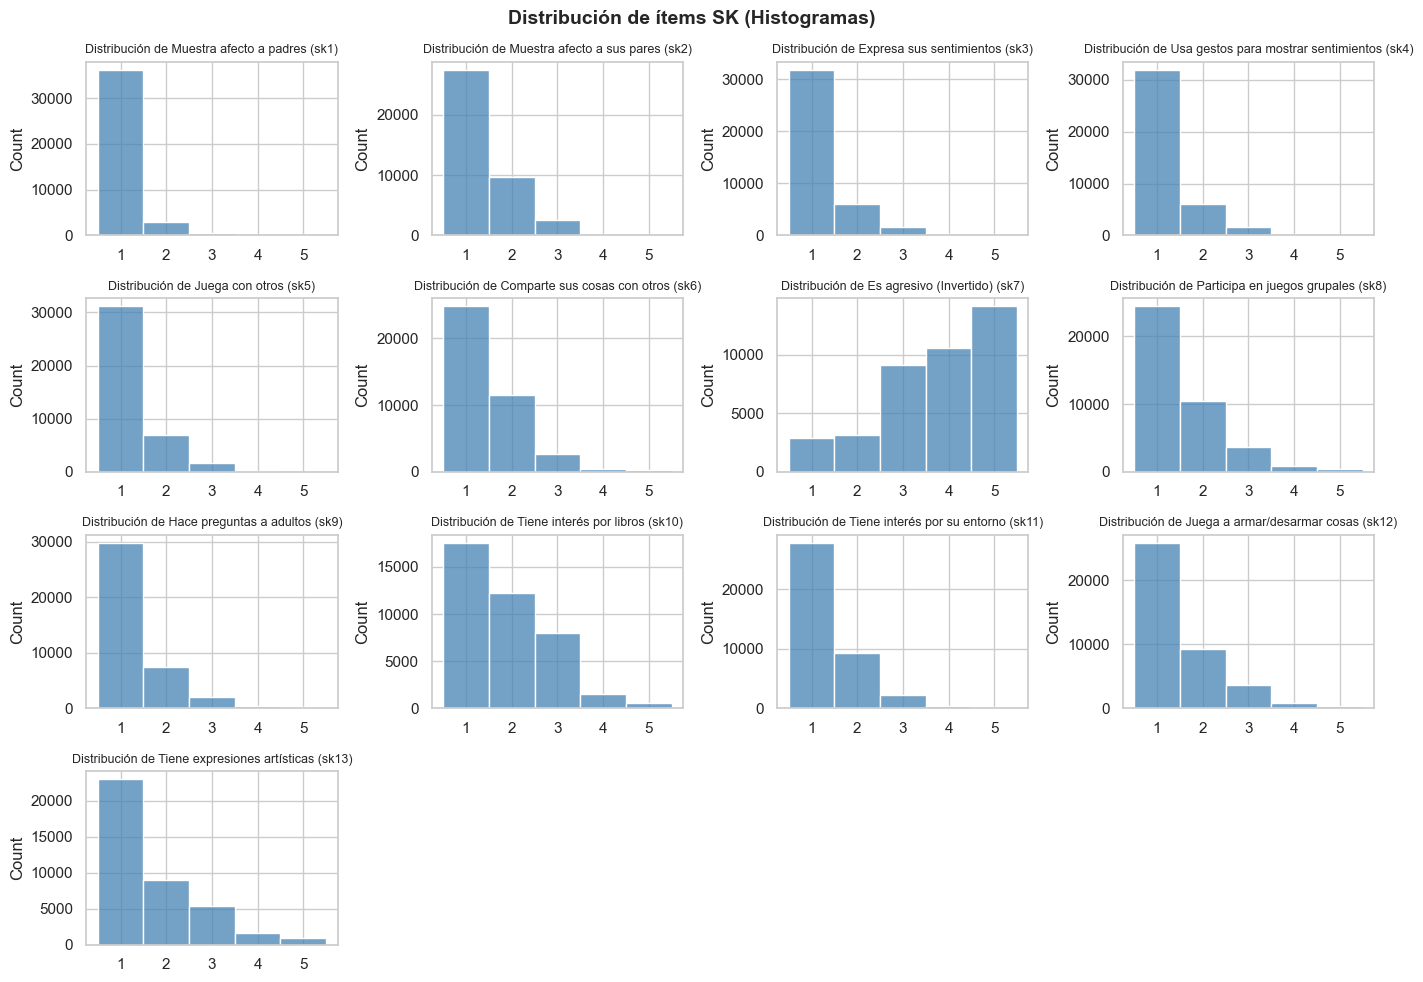

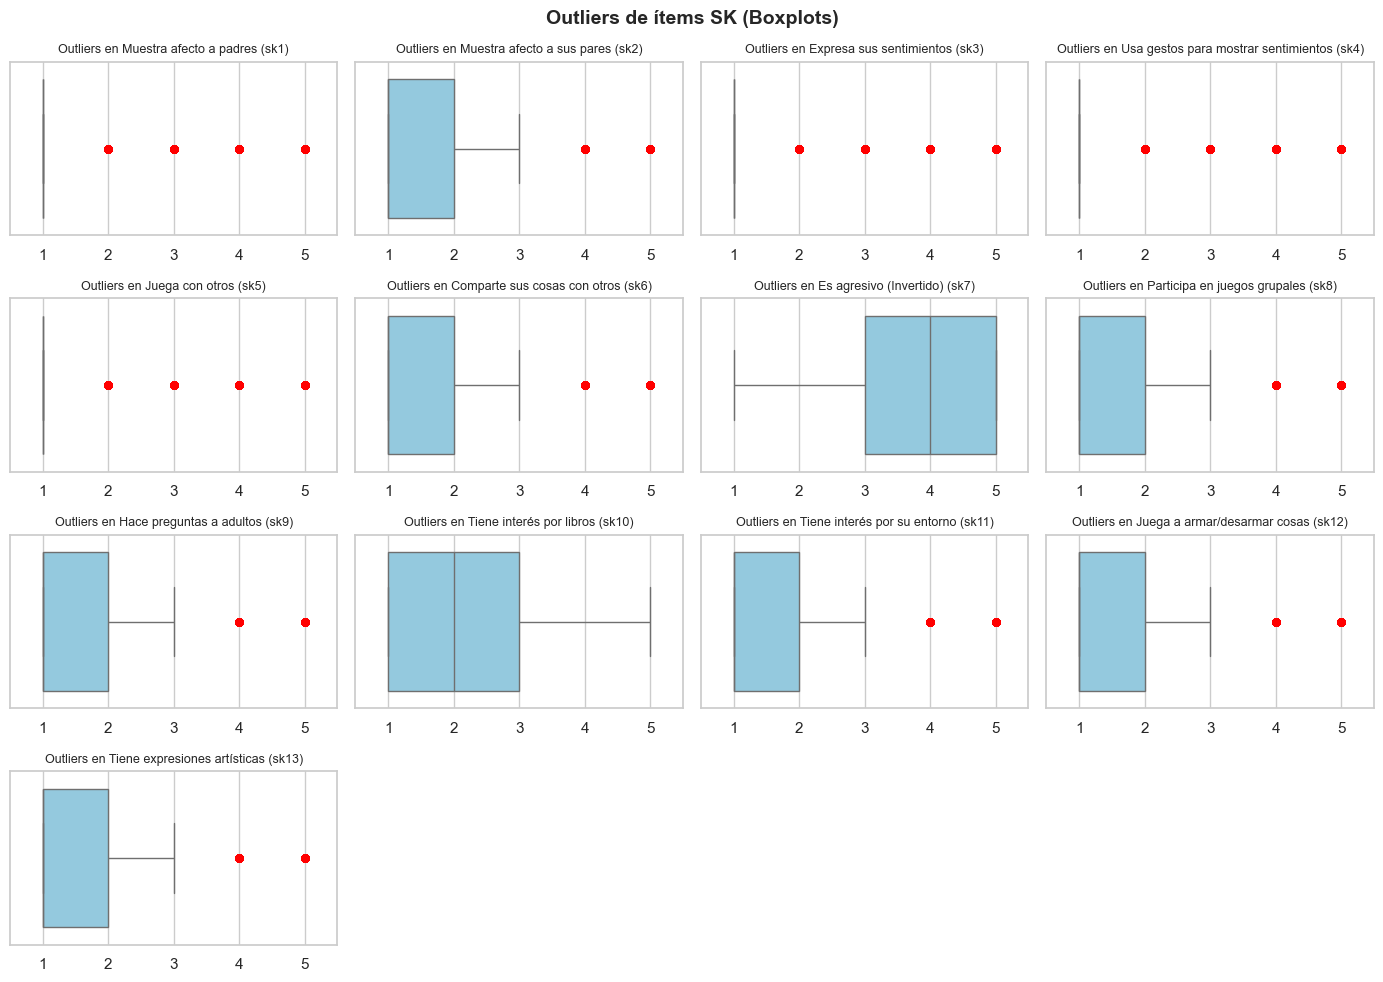

In [5]:
num_cols = ['edad', 'imce', 'educm', 'educp']
cat_cols = ['sexo', 'vive_padre', 'vive_madre', 'area', 'act_fisica', 'madre_work']

sk_descriptions = {
    'sk1': 'Muestra afecto a padres', 
    'sk2': 'Muestra afecto a sus pares', 
    'sk3': 'Expresa sus sentimientos',
    'sk4': 'Usa gestos para mostrar sentimientos', 
    'sk5': 'Juega con otros', 
    'sk6': 'Comparte sus cosas con otros',
    'sk7': 'Es agresivo (Invertido)', 
    'sk8': 'Participa en juegos grupales', 
    'sk9': 'Hace preguntas a adultos',
    'sk10': 'Tiene interés por libros', 
    'sk11': 'Tiene interés por su entorno', 
    'sk12': 'Juega a armar/desarmar cosas',
    'sk13': 'Tiene expresiones artísticas'
}

# FIGURA 1: Continuas (Histograms y Boxplots)
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[0, i], color='steelblue')
    sns.boxplot(x=df[col], ax=axes[1, i], color='skyblue')
plt.suptitle('Análisis de Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# FIGURA 2: Categóricas
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for col, ax in zip(cat_cols, axes.ravel()):
    sns.countplot(data=df, x=col, ax=ax, palette='Set2')
    ax.set_title(f'Distribución de {col}')
plt.suptitle('Distribución de Variables Categóricas', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# FIGURA 3: Distribución porcentual acumulada de items SK
df_sk_pct = df_sk.apply(lambda x: x.value_counts(normalize=True).sort_index() * 100).T
df_sk_pct.index = [f"{sk_descriptions[col]} ({col})" for col in df_sk.columns]
df_sk_pct.columns = ['1 (Siempre)', '2', '3 (A veces)', '4', '5 (Nunca)']
df_sk_pct.plot(kind='barh', stacked=True, cmap='RdYlGn_r', figsize=(12, 6)).legend(bbox_to_anchor=(1.02, 1))
plt.title('Distribución porcentual de ítems socioemocionales', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# FIGURA 4: Histogramas SK
fig, axes = plt.subplots(4, 4, figsize=(14, 10))
for ax, col in zip(axes.ravel(), df_sk.columns):
    sns.histplot(df_sk[col], discrete=True, ax=ax, color='steelblue')
    ax.set_title(f"Distribución de {sk_descriptions[col]} ({col})", fontsize=9)
    ax.set_xlabel(''); ax.set_xticks([1, 2, 3, 4, 5])
for ax in axes.ravel()[len(df_sk.columns):]: ax.axis('off')
plt.suptitle('Distribución de ítems SK (Histogramas)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# FIGURA 5: Boxplots SK (Horizontales con outliers rojos)
fig, axes = plt.subplots(4, 4, figsize=(14, 10))
for ax, col in zip(axes.ravel(), df_sk.columns):
    sns.boxplot(x=df_sk[col], ax=ax, color='skyblue', flierprops=dict(markerfacecolor='red', markeredgecolor='none'))
    ax.set_title(f"Outliers en {sk_descriptions[col]} ({col})", fontsize=9)
    ax.set_xlabel(''); ax.set_xlim(0.5, 5.5); ax.set_xticks([1, 2, 3, 4, 5])
for ax in axes.ravel()[len(df_sk.columns):]: ax.axis('off')
plt.suptitle('Outliers de ítems SK (Boxplots)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# 2. EFA 
Se realizaron tests de adecuación para verificar que las variables comparten suficiente varianza (KMO=0.87) y que existen correlaciones significativas entre ellas (Bartlett p<0.000), condiciones necesarias para poder hacer un EFA.

El Scree plot muestra que el número óptimo de factores, según el criterio del codo, es 3. En total, estos 3 factores explican el 34% de la varianza.

Al revisar el heatmap de cargas factoriales, se descubre que sk7 no carga de manera significativa a ningún factor, por lo que se decide excluirla.


### 2.1 Numero óptimo de factores 

KMO general: 0.8677
Bartlett sphericity: chi2 = 111743.27, p-value = 0.0000


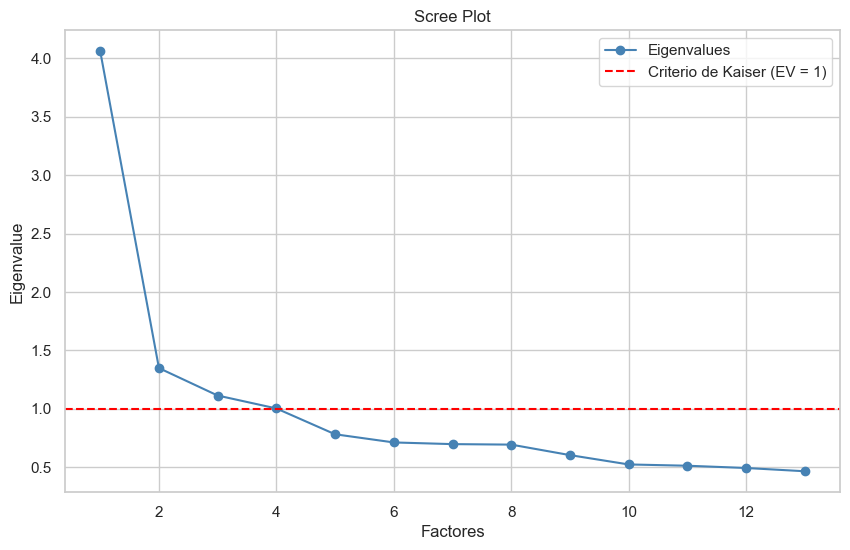

In [6]:
# Tests de adecuacion (KMO y Bartlett)
kmo_all, kmo_model = calculate_kmo(df_sk)
print(f'KMO general: {kmo_model:.4f}')
chi2, p_val = calculate_bartlett_sphericity(df_sk)
print(f'Bartlett sphericity: chi2 = {chi2:.2f}, p-value = {p_val:.4f}')


fa_init = FactorAnalyzer(n_factors=df_sk.shape[1], rotation=None).fit(df_sk)
ev, _ = fa_init.get_eigenvalues()
plt.plot(range(1, len(ev) + 1), ev, 'o-', color='steelblue', label='Eigenvalues')
plt.axhline(y=1, color='red', linestyle='--', label='Criterio de Kaiser (EV = 1)')
plt.title('Scree Plot')
plt.xlabel('Factores')
plt.ylabel('Eigenvalue')
plt.legend()
plt.show()

# Se define en 3 por criterio codo
n_kaiser = 3

### 2.2 EFA 

─── Loadings de Factores (Oblimin) ───
      Factor 1  Factor 2  Factor 3
sk1       0.02      0.59     -0.02
sk2      -0.00      0.50      0.22
sk3       0.03      0.64     -0.03
sk4       0.01      0.73     -0.01
sk5      -0.03      0.02      0.77
sk6       0.07      0.07      0.47
sk7      -0.04     -0.04     -0.13
sk8       0.21     -0.08      0.46
sk9       0.50      0.08      0.05
sk10      0.61     -0.03     -0.02
sk11      0.70      0.04      0.01
sk12      0.57     -0.03     -0.00
sk13      0.53      0.02     -0.01

─── Varianza Explicada ───────────────
                 Factor 1  Factor 2  Factor 3
SS Loadings          1.77      1.57      1.10
Proporción Var.      0.14      0.12      0.09
Var. Acumulada       0.14      0.26      0.34


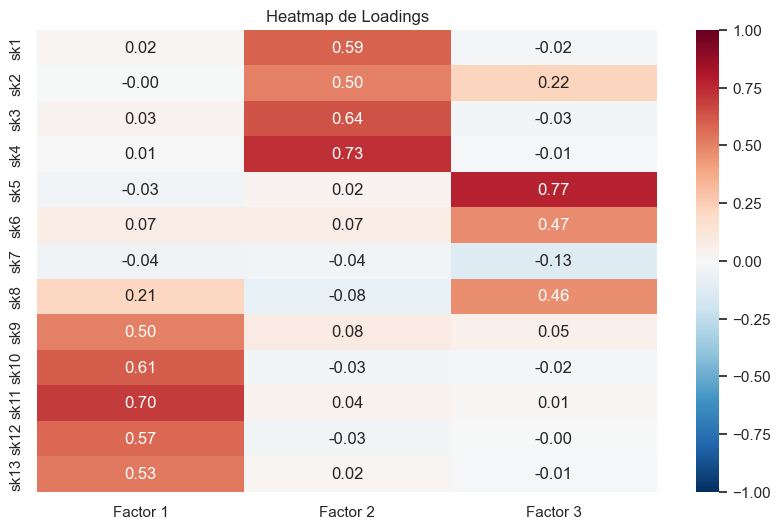

In [7]:
fa = FactorAnalyzer(n_factors=n_kaiser, rotation='oblimin').fit(df_sk)
loadings = pd.DataFrame(fa.loadings_, index=sk_labels, columns=[f'Factor {i+1}' for i in range(n_kaiser)])
print("─── Loadings de Factores (Oblimin) ───")
print(loadings.round(3))

var_explained = pd.DataFrame(fa.get_factor_variance(), index=['SS Loadings', 'Proporción Var.', 'Var. Acumulada'], columns=[f'Factor {i+1}' for i in range(n_kaiser)])
print("\n─── Varianza Explicada ───────────────")
print(var_explained.round(3))

sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Heatmap de Loadings')
plt.show()


# 3. CFA 
| Factor | Nombre | Variables |
|---|---|---|
|1|Curiosidad|sk9 + sk10 + sk11 + sk12 + sk13|
|2|Expresividad emocional|sk1 + sk2 + sk3 + sk4|
|3|Socialización|sk5 + sk6 + sk8|

**Factor 1: Curiosidad**
- 'sk9': 'Hace preguntas a adultos',
- 'sk10': 'Tiene interés por libros', 
- 'sk11': 'Tiene interés por su entorno', 
- 'sk12': 'Juega a armar/desarmar cosas',
- 'sk13': 'Tiene expresiones artísticas'

**Factor 2: Expresividad emocional**
- 'sk1': 'Muestra afecto a padres'
- 'sk2': 'Muestra afecto a sus pares', 
- 'sk3': 'Expresa sus sentimientos',
- 'sk4': 'Usa gestos para mostrar sentimientos', 

**Factor 3: Socialización**
- 'sk5': 'Juega con otros', 
- 'sk6': 'Comparte sus cosas con otros',
- 'sk8': 'Participa en juegos grupales',  se decide dejar en este factor por su significado y porque presenta mayor carga al factor 3 que al 1 





### 3.1 Especificación del modelo 

In [8]:
cfa_model_str = """
Curiosidad =~ sk9 + sk10 + sk11 + sk12 + sk13
Expresividad_Emocional =~ sk1 + sk2 + sk3 + sk4
Socializacion =~ sk5 + sk6 + sk8
"""
factor_col_names = ['Curiosidad', 'Expresividad_Emocional', 'Socializacion']

print("Especificación del modelo CFA:")
print(cfa_model_str)

Especificación del modelo CFA:

Curiosidad =~ sk9 + sk10 + sk11 + sk12 + sk13
Expresividad_Emocional =~ sk1 + sk2 + sk3 + sk4
Socializacion =~ sk5 + sk6 + sk8



### 3.2 Importancia de cada medida a cada factor

In [9]:
model_cfa = semopy.Model(cfa_model_str)
model_cfa.fit(df_sk)
results_cfa = model_cfa.inspect(std_est=True)
print("Loadings estandarizados del CFA (importancia de cada medida):")
print(results_cfa[results_cfa['op'] == '~'][['rval','lval','Est. Std','Std. Err','z-value','p-value']].round(4))

Loadings estandarizados del CFA (importancia de cada medida):
                      rval  lval  Est. Std Std. Err z-value p-value
0               Curiosidad   sk9      0.60        -       -       -
1               Curiosidad  sk10      0.56     0.02   84.46    0.00
2               Curiosidad  sk11      0.73     0.01   98.99    0.00
3               Curiosidad  sk12      0.55     0.01   82.96    0.00
4               Curiosidad  sk13      0.52     0.02   79.77    0.00
5   Expresividad_Emocional   sk1      0.59        -       -       -
6   Expresividad_Emocional   sk2      0.65     0.02   92.03    0.00
7   Expresividad_Emocional   sk3      0.63     0.02   90.81    0.00
8   Expresividad_Emocional   sk4      0.71     0.02   96.25    0.00
9            Socializacion   sk5      0.72        -       -       -
10           Socializacion   sk6      0.56     0.01   83.65    0.00
11           Socializacion   sk8      0.56     0.01   83.05    0.00


In [10]:
stats_cfa = semopy.calc_stats(model_cfa)
print("Índices de Ajuste del CFA:")
print(stats_cfa.T.round(3))

Índices de Ajuste del CFA:
                  Value
DoF               51.00
DoF Baseline      66.00
chi2            5860.52
chi2 p-value       0.00
chi2 Baseline 109696.13
CFI                0.95
GFI                0.95
AGFI               0.93
NFI                0.95
TLI                0.93
RMSEA              0.05
AIC               53.71
BIC              285.69
LogLik             0.15


### 3.3 Correlación entre factores

In [11]:
corr_factors = results_cfa[(results_cfa['op'] == '~~') & (results_cfa['lval'].isin(factor_col_names)) & (results_cfa['rval'].isin(factor_col_names)) & (results_cfa['lval'] != results_cfa['rval'])][['lval','rval','Est. Std']]
print("Correlaciones entre factores:")
print(corr_factors.round(4))

Correlaciones entre factores:
             lval                    rval  Est. Std
13     Curiosidad  Expresividad_Emocional      0.60
14     Curiosidad           Socializacion      0.59
17  Socializacion  Expresividad_Emocional      0.65


### 3.4 Guardar predicciones (Factor Scores)

In [12]:
# Predecimos y guardamos los factor scores en un nuevo DataFrame
df_scores = model_cfa.predict_factors(df_sk)[factor_col_names].copy()
print("Estadísticas de los factor scores guardados:")
print(df_scores.describe().round(3))

Estadísticas de los factor scores guardados:
       Curiosidad  Expresividad_Emocional  Socializacion
count    39815.00                39815.00       39815.00
mean        -0.00                   -0.00           0.00
std          0.35                    0.20           0.35
min         -0.34                   -0.15          -0.30
25%         -0.27                   -0.14          -0.26
50%         -0.11                   -0.08          -0.12
75%          0.17                    0.06           0.15
max          2.73                    1.95           3.01


## 4. Random Forest 


Se excluyen las personas desempleadas de madre_work y se remapea la variable como 0 = labor doméstica, 1 = empleada. Además, se agrega un parametro para balancear las clases.

Para encontrar la mejor configuración de hiperparámetros se usó GridSearchCV con validación cruzada de 5 pliegues (es decir, el dataset se divide en 5 partes; en cada iteración se entrena con 4 y se valida con 1, rotando hasta usar todas).

El modelo alcanzó una accuracy del 53% en el conjunto de prueba, es decir acierta en el 53% de los casos, apenas mejor que al azar. A pesar de aplicar el balance de clases, se sigue observando un sesgo hacia la clase empleada (recall = 0.75). 

El desempeño del modelo fue deficiente (F1-score = 0.49), sugiriendo que el modelo no logra discriminar adecuadamente entre ambas clases con las variables usadas.



### 4.1 Preparación del dataset de clasificacion


In [13]:
# Filtrar desempleadas
mask_clf = df['madre_work'] != 0
X_raw = df_scores[mask_clf.values].reset_index(drop=True)
y = df[mask_clf]['madre_work'].map({-1: 0, 1: 1}).reset_index(drop=True)

# Dividir en entrenamiento y prueba (70/30) como en clases
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.3, random_state=42)

# Estandarizar los features como en clases
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dimensiones de entrenamiento: {X_train_scaled.shape}")
print(f"Dimensiones de prueba: {X_test_scaled.shape}")
print("Distribución del target en entrenamiento:\n", y_train.value_counts())

Dimensiones de entrenamiento: (24981, 3)
Dimensiones de prueba: (10707, 3)
Distribución del target en entrenamiento:
 madre_work
1    13905
0    11076
Name: count, dtype: int64


### 4.2 Optimización de hiperparametros 


In [14]:
# Grid de hiperparámetros siguiendo la estructura del profesor (ml.ipynb)
# Se agrega class_weight='balanced' para manejar el desbalance moderado entre clases (~55/45)
param_grid_rf = {
    'max_depth': [8, 16, 32],
    'max_features': [1, 2, 3],
    'min_samples_leaf': [1, 3, 5],
    'min_samples_split': [2, 6],
    'n_estimators': [100, 200]
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_grid = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5, n_jobs=-1, verbose=1)
rf_grid.fit(X_train_scaled, y_train)

best_rf = rf_grid.best_estimator_
print(f"Mejores parámetros RF: {rf_grid.best_params_}")

cv_f1 = cross_val_score(best_rf, X_train_scaled, y_train, cv=5, scoring='f1_macro').mean()
print(f"Mejor F1-macro (CV): {cv_f1:.4f}")


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Mejores parámetros RF: {'max_depth': 8, 'max_features': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Mejor F1-macro (CV): 0.5035


### 4.3 Evaluacion del Random Forest


Accuracy en Test: 0.5339

Reporte de Clasificación:
                 precision    recall  f1-score   support

Labor domestica       0.47      0.27      0.35      4810
       Empleada       0.56      0.75      0.64      5897

       accuracy                           0.53     10707
      macro avg       0.51      0.51      0.49     10707
   weighted avg       0.52      0.53      0.51     10707



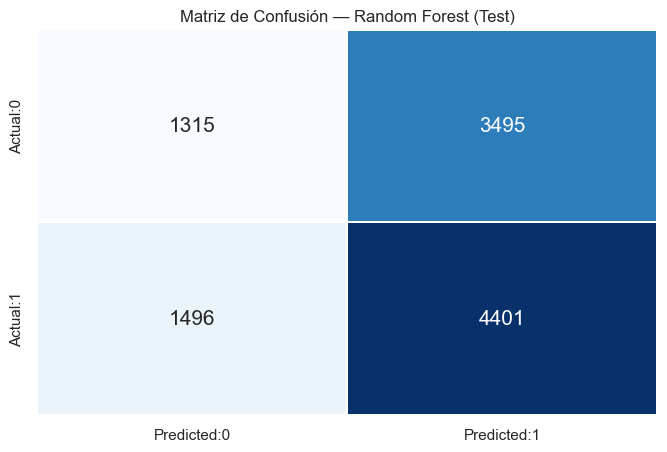

In [15]:
# Predicción en el conjunto de prueba
y_pred_rf = best_rf.predict(X_test_scaled)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy en Test: {accuracy_rf:.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_rf, target_names=['Labor domestica', 'Empleada']))

# Matriz de confusión estilo clases (heatmap de seaborn)
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 5))
conf_matrix_rf = pd.DataFrame(data=cm_rf, columns=['Predicted:0', 'Predicted:1'], index=['Actual:0', 'Actual:1'])
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', cbar=False, linewidths=0.1, annot_kws={'size': 15})
plt.title('Matriz de Confusión — Random Forest (Test)')
plt.show()

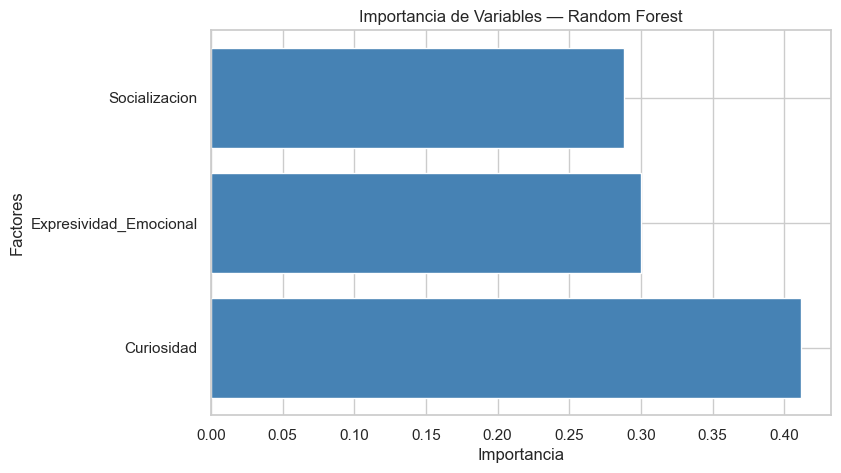

In [16]:
# Importancia de variables estilo clases
plt.figure(figsize=(8, 5))
plt.barh(X_raw.columns, best_rf.feature_importances_, color='steelblue')
plt.title('Importancia de Variables — Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Factores')
plt.show()

## 5. Comparación de Modelos: XGBoost, LinearSVC y Stacking

Se entrenaron los tres modelos con los mismos datos y se compararon con el Random Forest.
Se aplicó un balance de clases para todos los modelos. Para XGBoost se utilizó el parámetro scale_pos_weight, calculado como la razón entre el número de ejemplos de la clase mayoritaria y la minoritaria (0.797), lo que es equivalente al class_weight='balanced' usado en los demas.



| Modelo | Accuracy | F1-macro | F1-weighted | Velocidad |
|---|---|---|---|---|
| Random Forest | 0.53 | 0.49 | 0.51 | Lento (4m 40 s aprox) |
| XGBoost | 0.54 | 0.50 | 0.51 | Medio (2.4 s) |
| LinearSVC | 0.53 | 0.51 |0.52 | Rapido (0.1 s)|
| Stacking | 0.53 | 0.51 | 0.52 | Medio-lento (26.5s)|

Todos los modelos terminaron con un desempeño similar, con un mayor error en la clasificación de labor domestica, pero se observa una leve mejora en el modelo LinearSVC, además de ser el más rapido. 

De todas maneras, sigue siendo un bajo desempeño, es decir, los puntajes que se utilizaron de los features socioemocionales del niño no logran predecir la situacion laboral de la madre, lo cual podría indicar que la situacion laboral de la madre no está asociada a las habilidades del niño, pero habría que seguir analizando porque se están usando como predictoras, no como causales de ella.


### 5.1 XGBoost


In [17]:
# XGBoost con grid search
# scale_pos_weight = n_negativos / n_positivos para manejar desbalance (equivalente a class_weight='balanced')
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos
print(f"scale_pos_weight = {spw:.3f} (n_labor_dom={neg}, n_empleada={pos})")

xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=spw)
param_grid_xgb = {
    'learning_rate': [0.02, 0.1],
    'max_depth': [3, 5],
    'n_estimators': [100, 200]
}

xgb_grid = GridSearchCV(estimator=xgb_model, param_grid=param_grid_xgb, cv=5, n_jobs=-1)
xgb_grid.fit(X_train_scaled, y_train)

best_xgb = xgb_grid.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_scaled)

print(f"Mejores parámetros XGBoost: {xgb_grid.best_params_}")
print("\nResultados XGBoost en Test:")
print(classification_report(y_test, y_pred_xgb, target_names=['Labor domestica', 'Empleada']))


scale_pos_weight = 0.797 (n_labor_dom=11076, n_empleada=13905)
Mejores parámetros XGBoost: {'learning_rate': 0.02, 'max_depth': 3, 'n_estimators': 200}

Resultados XGBoost en Test:
                 precision    recall  f1-score   support

Labor domestica       0.47      0.28      0.35      4810
       Empleada       0.56      0.75      0.64      5897

       accuracy                           0.54     10707
      macro avg       0.52      0.51      0.50     10707
   weighted avg       0.52      0.54      0.51     10707



### 5.2 Support Vector Machine (LinearSVC)


In [18]:
# LinearSVC: equivalente a SVC(kernel=linear) pero mucho más rápido para datasets grandes.
# SVC con kernel RBF es inviable aquí (>35k filas, tardaría horas).
# El profesor usa LinearSVC en Sentiment_Analysis.ipynb, adoptamos el mismo criterio.
# class_weight='balanced' para corregir el desbalance moderado entre clases.
param_grid_svm = {
    'C': [0.01, 0.1, 1, 10]
}

svm_model = LinearSVC(random_state=42, max_iter=2000, class_weight='balanced')
svm_grid = GridSearchCV(estimator=svm_model, param_grid=param_grid_svm, cv=5, n_jobs=-1)
svm_grid.fit(X_train_scaled, y_train)

best_svm = svm_grid.best_estimator_
y_pred_svm = best_svm.predict(X_test_scaled)

print(f"Mejores parámetros SVM: {svm_grid.best_params_}")
print("\nResultados SVM (LinearSVC) en Test:")
print(classification_report(y_test, y_pred_svm, target_names=['Labor domestica', 'Empleada']))


Mejores parámetros SVM: {'C': 1}

Resultados SVM (LinearSVC) en Test:
                 precision    recall  f1-score   support

Labor domestica       0.47      0.39      0.42      4810
       Empleada       0.56      0.64      0.60      5897

       accuracy                           0.53     10707
      macro avg       0.51      0.51      0.51     10707
   weighted avg       0.52      0.53      0.52     10707



### 5.3 Stacking


In [19]:
# Estimadores siguiendo la estructura del profesor (ml.ipynb)
# Se agrega class_weight='balanced' a RF y LogisticRegression final para consistencia
estimators = [
    ('rf', best_rf),
    ('boost', GradientBoostingClassifier(n_estimators=300, learning_rate=0.04, max_depth=8, random_state=42)),
    ('svc', LinearSVC(C=1, random_state=42, max_iter=2000, class_weight='balanced'))
]

stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(random_state=42, class_weight='balanced'),
    cv=5, n_jobs=-1
)
stack_clf.fit(X_train_scaled, y_train)

y_pred_stack = stack_clf.predict(X_test_scaled)
print("Resultados Stacking en Test:")
print(classification_report(y_test, y_pred_stack, target_names=['Labor domestica', 'Empleada']))


Resultados Stacking en Test:
                 precision    recall  f1-score   support

Labor domestica       0.47      0.37      0.42      4810
       Empleada       0.56      0.66      0.61      5897

       accuracy                           0.53     10707
      macro avg       0.52      0.51      0.51     10707
   weighted avg       0.52      0.53      0.52     10707



### 5.4 Comparación de resultados y matrices de confusión


In [20]:
modelos = ['Random Forest', 'XGBoost', 'SVM (SVC)', 'Stacking']
preds = [y_pred_rf, y_pred_xgb, y_pred_svm, y_pred_stack]

results_table = pd.DataFrame({
    'Accuracy': [accuracy_score(y_test, p) for p in preds],
    'F1-macro': [f1_score(y_test, p, average='macro') for p in preds],
    'F1-weighted': [f1_score(y_test, p, average='weighted') for p in preds]
}, index=modelos)
print(results_table.round(4))


               Accuracy  F1-macro  F1-weighted
Random Forest      0.53      0.49         0.51
XGBoost            0.54      0.50         0.51
SVM (SVC)          0.53      0.51         0.52
Stacking           0.53      0.51         0.52


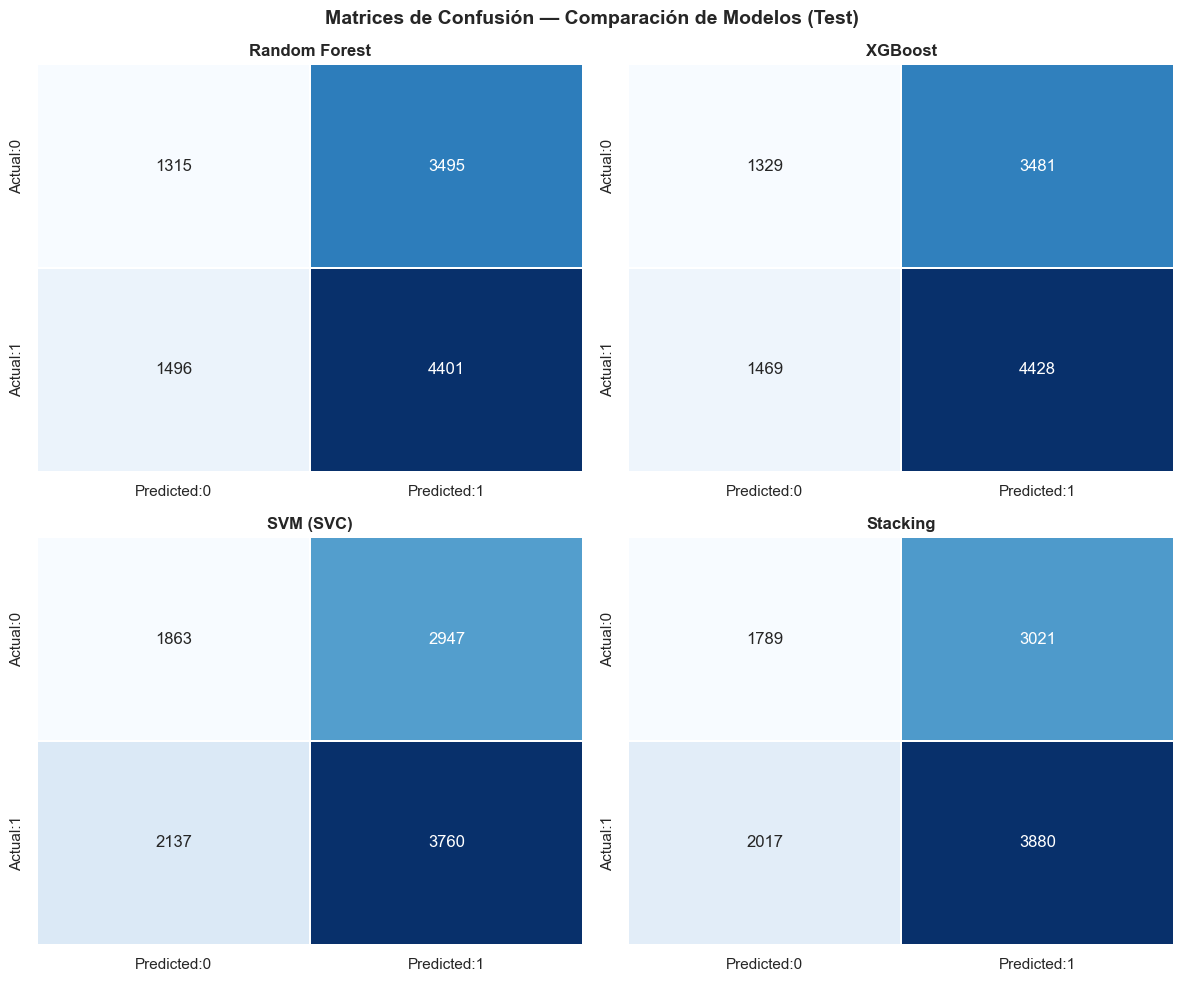

In [21]:
# Graficar las matrices de confusión estilo clases
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, name, pred in zip(axes.ravel(), modelos, preds):
    cm = confusion_matrix(y_test, pred)
    conf_matrix = pd.DataFrame(data=cm, columns=['Predicted:0', 'Predicted:1'], index=['Actual:0', 'Actual:1'])
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, linewidths=0.1, ax=ax)
    ax.set_title(name, fontsize=12, fontweight='bold')
plt.suptitle('Matrices de Confusión — Comparación de Modelos (Test)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Clustering: IMCE y Actividad Física

Se usó K-Means para agrupar a los estudiantes según su IMCE y su nivel de actividad física.
Se evaluaron entre 2 y 8 clusters y se elige 3 por el criterio del codo

| Cluster | N | IMCE promedio | Act. Física promedio |
|---|---|---|---|
| 0 | 5.150 | 0.88 | 4.62 | 
| 1 | 18.586 | 0.01 | 2.24 | 
| 2 | 16.079 | 2.22 | 2.25 | 

El cluster 0 es el más activo, con una actividad física promedio del doble que los de los demas clusters (act_fisica = 4.62), pero presenta un IMCE de 0.88, levemente mayor al promedio, lo que podría explicarse a una mayor masa muscular, pero no se puede saber con los datos. Este grupo es consistente con lo que se espera de la relación entre actividad fisica y peso corporal

El cluster 1 con actividad fisica media presenta el IMCE mas bajo, es decir un peso normal. Por otro lado, el grupo 2, quien presenta un alto IMCE, presenta una actividad fisica similar al cluster 1, lo que indica que el sobrepeso de este grupo no es explicado por la actividad física, sino por otros factores externos desconocidos.



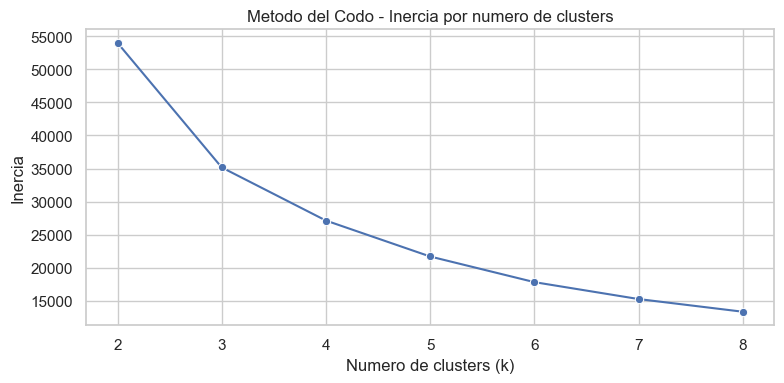

In [22]:
X_clust = StandardScaler().fit_transform(df[["imce", "act_fisica"]].dropna())

K_range = range(2, 9)
inercias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_clust).inertia_ for k in K_range]

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(x=list(K_range), y=inercias, marker="o", ax=ax)
ax.set_title("Metodo del Codo - Inercia por numero de clusters")
ax.set_xlabel("Numero de clusters (k)")
ax.set_ylabel("Inercia")
plt.tight_layout()
plt.show()

k_opt = 3

             n  imce_mean  act_mean
cluster                            
0         5150       0.88      4.62
1        18586       0.01      2.24
2        16079       2.22      2.25

-> Cluster con mayor IMCE promedio: Cluster 2


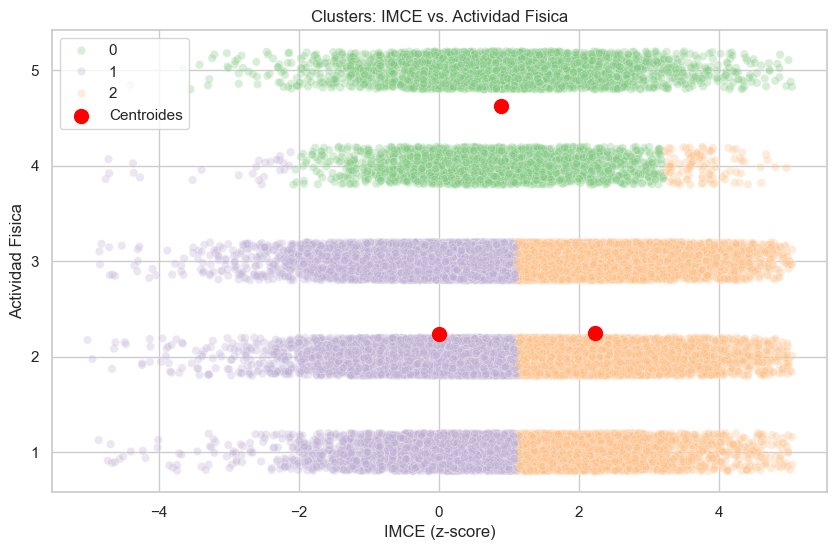

In [23]:
df_clust = df[["imce", "act_fisica"]].copy()
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df_clust["cluster"] = kmeans.fit_predict(X_clust)

# Estadisticas por cluster
cluster_stats = df_clust.groupby("cluster").agg(
    n=("imce", "count"),
    imce_mean=("imce", "mean"),
    act_mean=("act_fisica", "mean")
).round(3)
print(cluster_stats)

cluster_mayor_imce = int(cluster_stats["imce_mean"].idxmax())
print(f"\n-> Cluster con mayor IMCE promedio: Cluster {cluster_mayor_imce}")

# Centroides en escala ORIGINAL (groupby sobre datos sin escalar)
centroids = df_clust.groupby("cluster")[["imce", "act_fisica"]].mean().values

# Scatter estilo clases con jitter en act_fisica (es discreta)
np.random.seed(42)
df_plot = df_clust.copy()
df_plot["act_fisica"] = df_plot["act_fisica"] + np.random.uniform(-0.2, 0.2, size=len(df_plot))

plt.figure(figsize=(10, 6))
Data_kmean = df_plot.copy()
sns.scatterplot(data=Data_kmean, x="imce", y="act_fisica", hue="cluster",
                palette="Accent", alpha=0.3)
plt.scatter(centroids[:, 0], centroids[:, 1], c="red", s=100, zorder=5, label="Centroides")
plt.xlabel("IMCE (z-score)", fontsize=12)
plt.ylabel("Actividad Fisica", fontsize=12)
plt.title("Clusters: IMCE vs. Actividad Fisica")
plt.legend()
plt.show()


## 7. Modelo en el Subgrupo con Mayor IMCE (Cluster 2)

Se vuelve a estimar el modelo LinearSVC usando solo los datos del Cluster 2, el grupo con mayor IMCE promedio, con el objetivo de ver si el modelo mejora al enfocarse en ese subgrupo especifico.


No se ve diferencia en los resultados entre el subgrupo y la muestra completa, confirmando que las habilidades socioemocionales del niño no son buenas predictoras para la situacion laboral de la madre independiente del perfil nutricional del niño.


In [24]:
# Subgrupo: cluster con mayor IMCE
df_sub = df.loc[df_clust[df_clust["cluster"] == cluster_mayor_imce].index].copy()
df_sub = df_sub[df_sub["madre_work"] != 0]

# Factor scores para el subgrupo
X_sub = model_cfa.predict_factors(df_sub[sk_labels])[factor_col_names].copy().reset_index(drop=True)
y_sub = df_sub["madre_work"].map({-1: 0, 1: 1}).reset_index(drop=True)

print(f"Subgrupo (cluster {cluster_mayor_imce}): {X_sub.shape[0]} estudiantes")
print("Distribucion del target:\n", y_sub.value_counts())

# Train/test split y escalado
X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(X_sub, y_sub, test_size=0.3, random_state=42)
scaler_sub = StandardScaler()
X_train_sub_scaled = scaler_sub.fit_transform(X_train_sub)
X_test_sub_scaled = scaler_sub.transform(X_test_sub)

# LinearSVC con mismos parametros que inciso 5
model_sub = LinearSVC(C=1, random_state=42, max_iter=2000, class_weight="balanced")
model_sub.fit(X_train_sub_scaled, y_train_sub)
y_pred_sub = model_sub.predict(X_test_sub_scaled)

print("\nResultados LinearSVC en Subgrupo (Cluster 2):")
print(classification_report(y_test_sub, y_pred_sub, target_names=["Labor domestica", "Empleada"]))

# Comparacion: muestra completa vs subgrupo
comparison = pd.DataFrame({
    "Muestra completa": [
        accuracy_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_svm, average="macro"),
        len(y_test)
    ],
    "Subgrupo Cluster 2": [
        accuracy_score(y_test_sub, y_pred_sub),
        f1_score(y_test_sub, y_pred_sub, average="macro"),
        len(y_test_sub)
    ]
}, index=["Accuracy", "F1-macro", "N Test"])
print(comparison.round(5))


Subgrupo (cluster 2): 14361 estudiantes
Distribucion del target:
 madre_work
1    8151
0    6210
Name: count, dtype: int64

Resultados LinearSVC en Subgrupo (Cluster 2):
                 precision    recall  f1-score   support

Labor domestica       0.45      0.37      0.40      1878
       Empleada       0.57      0.65      0.61      2431

       accuracy                           0.53      4309
      macro avg       0.51      0.51      0.51      4309
   weighted avg       0.52      0.53      0.52      4309

          Muestra completa  Subgrupo Cluster 2
Accuracy              0.53                0.53
F1-macro              0.51                0.51
N Test            10707.00             4309.00


## 8. Análisis de Texto: Narrative y Situación Laboral de la Madre

Se utilizó la función del notebook de referencia para limpiar el texto de la variable narrative, eliminando stopwords en español, puntuación y caracteres especiales. Se vectorizaron los textos con CountVectorizer. Luego se entrenó un modelo LinearSVC con esos datos.

El modelo tiene una accuracy de 55% y un F1-macro del 45%. Al compararlo con el SVM numerico (accuracy = 0.53, F1-macro = 0.51), la accuracy mejora levemente, pero el F1-macro baja de manera considerable, lo que se explica por el sesgo hacia la clase empleada (recall = 0.90)

Esto puede verse explicado porque la variable narrative fue construida a partir de las mismas variables sk1 a sk13, por lo que el texto no aporta información nueva que pueda ser utilziada para mejorar la predicción. Como conclusión, ni usando los puntajes socioemocionales ni el texto se logra predecir adecuadamente la situación laboral de la madre.


Resultados LinearSVC con texto (Test):
                 precision    recall  f1-score   support

Labor domestica       0.51      0.13      0.20      4810
       Empleada       0.56      0.90      0.69      5897

       accuracy                           0.55     10707
      macro avg       0.53      0.51      0.45     10707
   weighted avg       0.54      0.55      0.47     10707



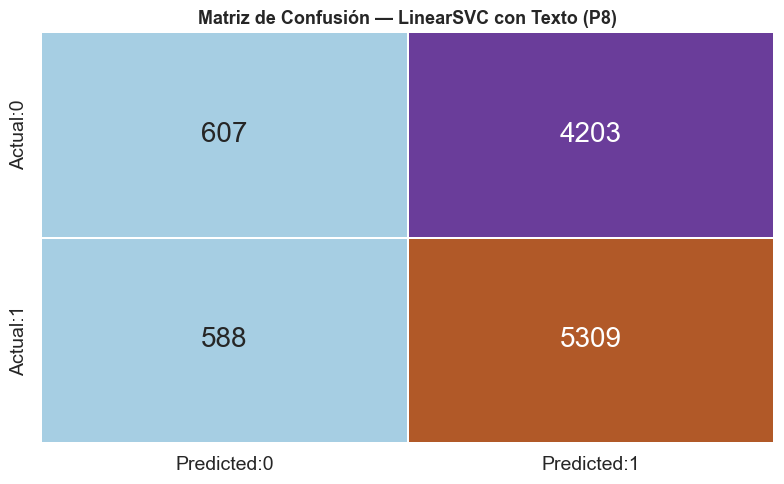


Comparación P5 vs P8:
             SVM P5 (factor scores)  LinearSVC P8 (texto)
Accuracy                       0.53                  0.55
F1-macro                       0.51                  0.45
F1-weighted                    0.52                  0.47


In [25]:
# 8.1 Preprocesamiento del texto — pipeline del notebook de referencia (Sentiment_Analysis.ipynb)
nltk.download('stopwords', quiet=True)

def tweet_to_words(tweet):
    """Limpieza de texto basada en el notebook de referencia del profesor."""
    letters_only = re.sub(r'#([A-Za-z_\u00c0-\u00ff]+)', ' ', tweet)
    letters_only = re.sub(r'[^a-zA-Z\u00c0-\u00ff\s]', ' ', letters_only)
    words = letters_only.lower().split()
    stops = set(stopwords.words('spanish'))
    meaningful_words = [w for w in words if w not in stops]
    return ' '.join(meaningful_words)

df['narrative_clean'] = df['narrative'].apply(tweet_to_words)

# 8.2 Preparación y división de datos (excluir desempleadas, igual que P5)
df_nlp = df[df['madre_work'] != 0].copy()
X_nlp = df_nlp['narrative_clean']
y_nlp = df_nlp['madre_work'].map({-1: 0, 1: 1})

X_train_nlp, X_test_nlp, y_train_nlp, y_test_nlp = train_test_split(
    X_nlp, y_nlp, test_size=0.3, random_state=42
)

# 8.3 Vectorización — CountVectorizer estilo referencia, ajustado al dataset
vect_tunned = CountVectorizer(ngram_range=(1, 3), min_df=0.01, max_df=0.9, max_features=500)
X_train_dtm = vect_tunned.fit_transform(X_train_nlp)
X_test_dtm  = vect_tunned.transform(X_test_nlp)

# 8.4 Modelo LinearSVC — igual que Sentiment_Analysis.ipynb
model_nlp = LinearSVC(random_state=10)
model_nlp.fit(X_train_dtm, y_train_nlp)
pred_nlp = model_nlp.predict(X_test_dtm)

print('Resultados LinearSVC con texto (Test):')
print(classification_report(y_test_nlp, pred_nlp, target_names=['Labor domestica', 'Empleada']))

# 8.5 Matriz de confusión — estilo Sentiment_Analysis.ipynb
cm_nlp = confusion_matrix(y_test_nlp, pred_nlp)
conf_matrix_nlp = pd.DataFrame(
    data=cm_nlp,
    columns=['Predicted:0', 'Predicted:1'],
    index=['Actual:0', 'Actual:1']
)
plt.figure(figsize=(8, 5))
sns.heatmap(conf_matrix_nlp, annot=True, fmt='d', cmap='Paired',
            cbar=False, linewidths=0.1, annot_kws={'size': 20})
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title('Matriz de Confusión — LinearSVC con Texto (P8)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 8.6 Comparación directa con el modelo SVM de la Pregunta 5
comparison_nlp = pd.DataFrame({
    'SVM P5 (factor scores)': [
        accuracy_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_svm, average='macro'),
        f1_score(y_test, y_pred_svm, average='weighted')
    ],
    'LinearSVC P8 (texto)': [
        accuracy_score(y_test_nlp, pred_nlp),
        f1_score(y_test_nlp, pred_nlp, average='macro'),
        f1_score(y_test_nlp, pred_nlp, average='weighted')
    ]
}, index=['Accuracy', 'F1-macro', 'F1-weighted'])
print('\nComparación P5 vs P8:')
print(comparison_nlp.round(4))
